# Cell segmentation & clustering


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from session_info2 import session_info

import spatiomic as so

## Data loading


In [2]:
img_data = so.data.read().read_tiff("./data/nuclei_mouse.tiff", input_dimension_order="CYX")
img_data.shape

(1750, 1750, 1)

## Cellpose segmentation


In [3]:
masks, flows, styles = so.segment.cellpose().predict(img_data)



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	darwin 
python version: 	3.13.5 
torch version:  	2.8.0! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




We can extend the masks, e.g., to also include the cytoplasm.


In [4]:
extended_masks = so.segment.extend_mask(masks, dilation_pixels=20)

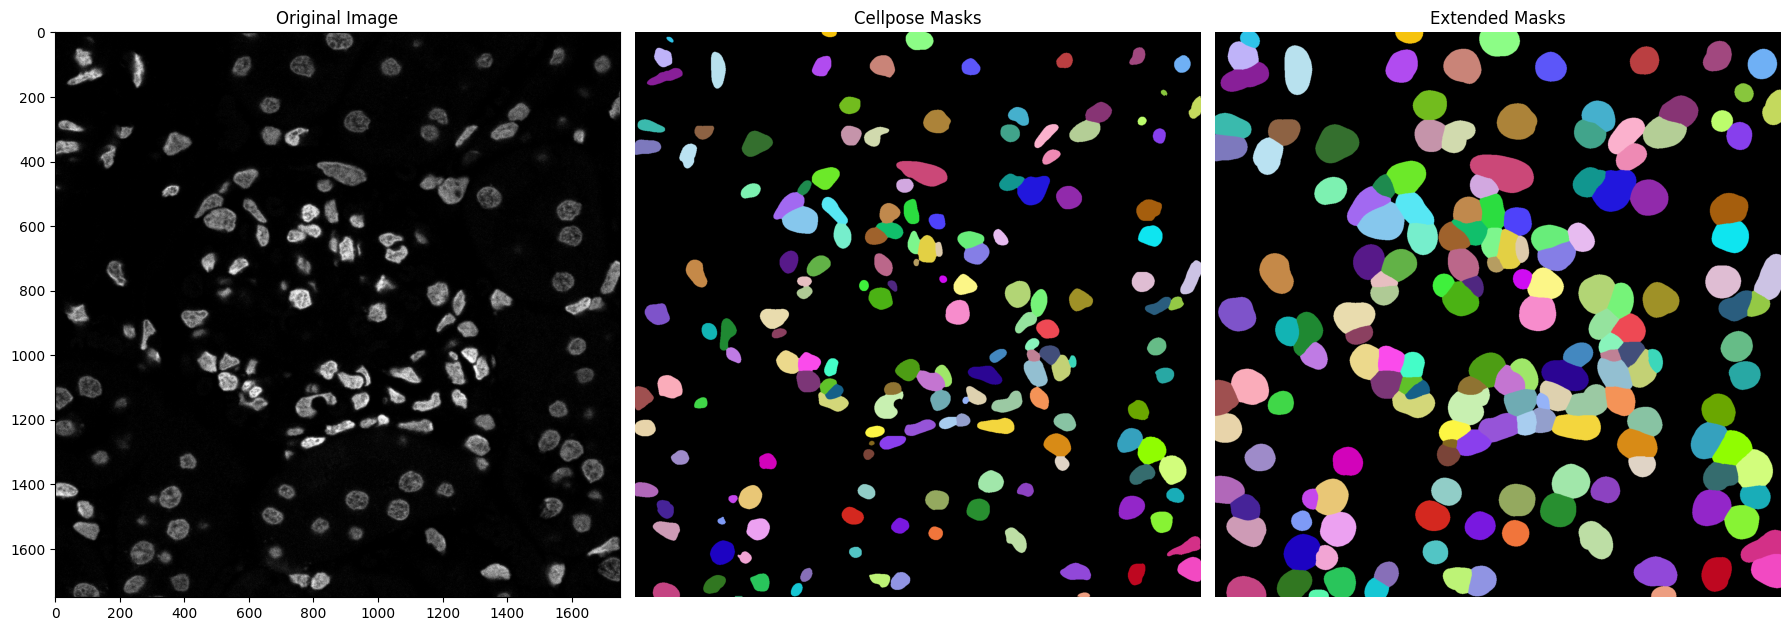

In [5]:
fig, (axes) = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_data[..., 0], cmap="gray")
axes[0].set_title("Original Image")
so.plot.cluster_image(masks, ax=axes[1], show_colorbar=False, title="Cellpose Masks")
so.plot.cluster_image(extended_masks, ax=axes[2], show_colorbar=False, title="Extended Masks")
plt.tight_layout()
plt.show()

## Load a pixel-clustered image


In [6]:
labelled_image = np.load("./data/nuclei_mouse_clustered.npy")

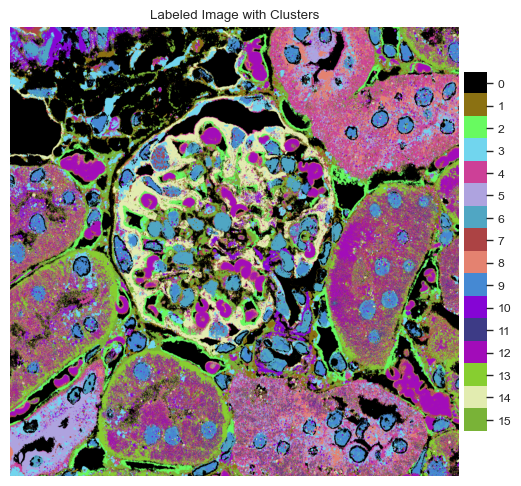

In [7]:
fig = so.plot.cluster_image(labelled_image, title="Labeled Image with Clusters")

## Quantify pixel-level features at the cell-level


In [8]:
cluster_counts = so.segment.count_clusters(
    labelled_image,
    extended_masks,
    cluster_count=np.max(labelled_image) + 1,
    normalize=True,
)
cluster_counts.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
mask_region,,,,,,,,,,,,,,,,
1,0.764427,0.079255,0.000000,0.000000,0.003652,0.001096,0.000000,0.001461,0.001096,0.014609,0.006209,0.000000,0.000000,0.006574,0.003652,0.117969
2,0.414141,0.080926,0.001175,0.077637,0.001057,0.002936,0.055556,0.027249,0.007987,0.093611,0.005755,0.001409,0.011510,0.007869,0.041931,0.169251
3,0.038026,0.132282,0.000405,0.077670,0.009709,0.000405,0.000000,0.316343,0.011327,0.053803,0.163026,0.000000,0.018204,0.025890,0.064320,0.088592
4,0.123294,0.040478,0.024349,0.036600,0.009770,0.007134,0.016129,0.063431,0.019541,0.254498,0.026210,0.018300,0.022953,0.234957,0.002636,0.099721
5,0.115942,0.074669,0.000000,0.019219,0.011027,0.019376,0.361531,0.020006,0.011500,0.124291,0.179742,0.003938,0.000473,0.046314,0.003466,0.008507


## Cluster cells based on pixel-level clusters


In [9]:
knn_graph_counts = so.neighbor.knn_graph().create(
    cluster_counts.values,
    neighbor_count=10,
    distance_metric="cosine",
)
communities_counts, modularity_counts = so.cluster.leiden().predict(knn_graph_counts, resolution=1.0)

/Users/au734063/Documents/spatiomic/spatiomic/neighbor/_knn_graph.py:66: UserWarning: Could not import cuml implementation. Switching to non-GPU implementation.
  neighbor_finder = get_neighbor_finder(


In [10]:
clustered_cells = so.segment.assign_communities(extended_masks, communities_counts)

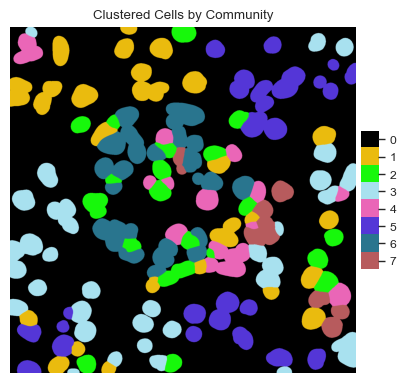

In [11]:
fig = so.plot.cluster_image(clustered_cells, title="Clustered Cells by Community", figsize=(4, 4))

## Cell-level clustering based on marker expression

To download the data, please run `full_example.ipynb` first.


In [12]:
image = so.data.read().read_tiff("./data/mouse_cgn/265 g2.tif", input_dimension_order="CYX")
channels_data = list(pd.read_csv("./data/mouse_cgn/channel_names.csv", header=0).T.to_numpy()[0])

In [13]:
image = so.process.normalize().fit_transform(image)

/Users/au734063/Documents/spatiomic/spatiomic/_internal/_anndata_method.py:216: UserWarning: Data does not appear to be a numpy/cupy float, casting to numpy float32.
  result = method(*method_args, *processed_args, **kwargs)


In [14]:
df_marker_quantification = so.segment.quantify_markers(
    image=image,
    masks=extended_masks,
    quantification_function=lambda x: np.percentile(x, 90),
    channel_names=channels_data,
    exclude_background=True,
)
df_marker_quantification.head(5)

,ANXA,SNP,CD3,Podocin,5MC,DACH1,Podoplanin,GR,AQP2,Integrin-B1,...,GATA3,rab7,LaminB,OAT1,PDGFR,Calreticulin,LMP7,RAP1GAP,DRAQ5,DAPI
mask_region,,,,,,,,,,,,,,,,,,,,,
1,0.113725,0.133333,0.107059,0.074510,0.146275,0.101961,0.031373,0.054902,0.019608,0.090196,...,0.027451,0.058824,0.047059,0.035294,0.114173,0.062745,0.039216,0.031373,0.023529,0.101961
2,0.105882,0.098039,0.117647,0.062745,0.203922,0.058824,0.243137,0.211765,0.019608,0.239216,...,0.058824,0.090196,0.262745,0.070588,0.196850,0.250980,0.113725,0.066667,0.349020,0.196078
3,0.309804,0.117647,0.133333,0.074510,0.227451,0.192157,0.031373,0.070588,0.023529,0.247059,...,0.098039,0.125490,0.054902,0.090196,0.074803,0.230980,0.258824,0.098039,0.027451,0.082353
4,0.160784,0.149020,0.188235,0.109804,0.329412,0.101961,0.027451,0.859999,0.027451,0.321569,...,0.090196,0.160784,0.376471,0.286275,0.169291,0.192157,0.176471,0.109804,0.372549,0.258824
5,0.137255,0.125490,0.125490,0.099215,0.125490,0.160784,0.027451,0.121569,0.019608,0.105882,...,0.243137,0.129412,0.152941,0.090196,0.125984,0.160784,0.207843,0.086275,0.454902,0.278431


In [15]:
knn_graph_markers = so.neighbor.knn_graph().create(
    df_marker_quantification.values,
    neighbor_count=10,
    distance_metric="cosine",
)
communities_markers, modularity_markers = so.cluster.leiden().predict(knn_graph_markers, resolution=1.0)

/Users/au734063/Documents/spatiomic/spatiomic/neighbor/_knn_graph.py:66: UserWarning: Could not import cuml implementation. Switching to non-GPU implementation.
  neighbor_finder = get_neighbor_finder(


In [16]:
clustered_cells_markers = so.segment.assign_communities(extended_masks, communities_markers)

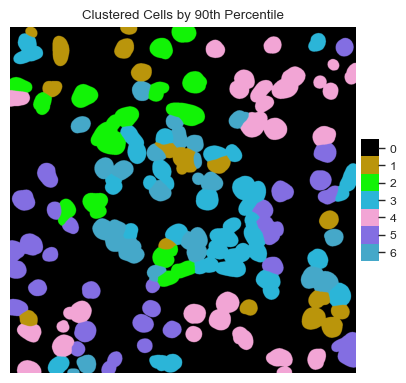

In [17]:
fig = so.plot.cluster_image(clustered_cells_markers, title="Clustered Cells by 90th Percentile", figsize=(4, 4))

## Plot the results


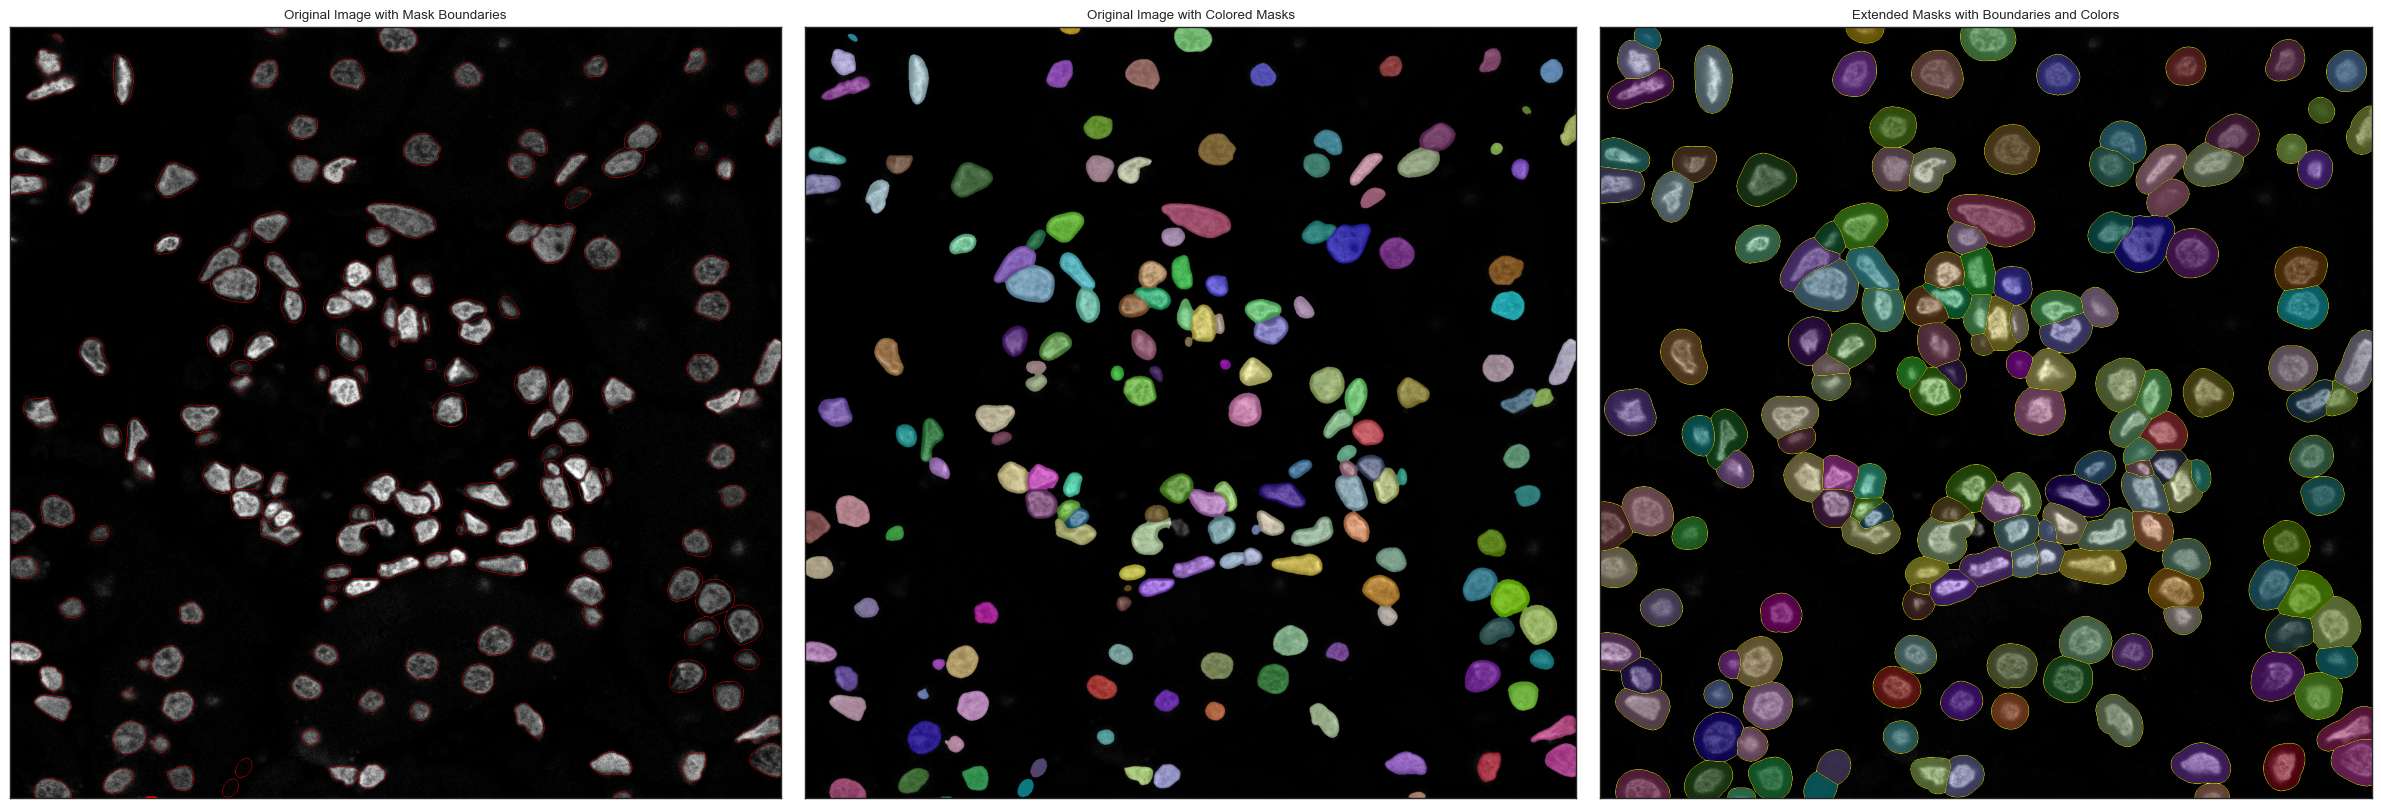

In [18]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

ax1 = so.plot.segmentation_overlay(
    img_data[..., 0],
    masks,
    boundary_color="#FF0000",
    show_boundaries=True,
    show_masks=False,
    ax=ax1,
    figsize=(8, 6),
)
ax1.set_title("Original Image with Mask Boundaries")

ax2 = so.plot.segmentation_overlay(
    img_data[..., 0],
    masks,
    show_boundaries=False,
    show_masks=True,
    mask_alpha=0.6,
    ax=ax2,
    figsize=(8, 6),
)
ax2.set_title("Original Image with Colored Masks")

ax3 = so.plot.segmentation_overlay(
    img_data[..., 0],
    extended_masks,
    boundary_color="#FFFF00",
    show_boundaries=True,
    show_masks=True,
    mask_alpha=0.4,
    ax=ax3,
    figsize=(8, 6),
)
ax3.set_title("Extended Masks with Boundaries and Colors")

plt.tight_layout()

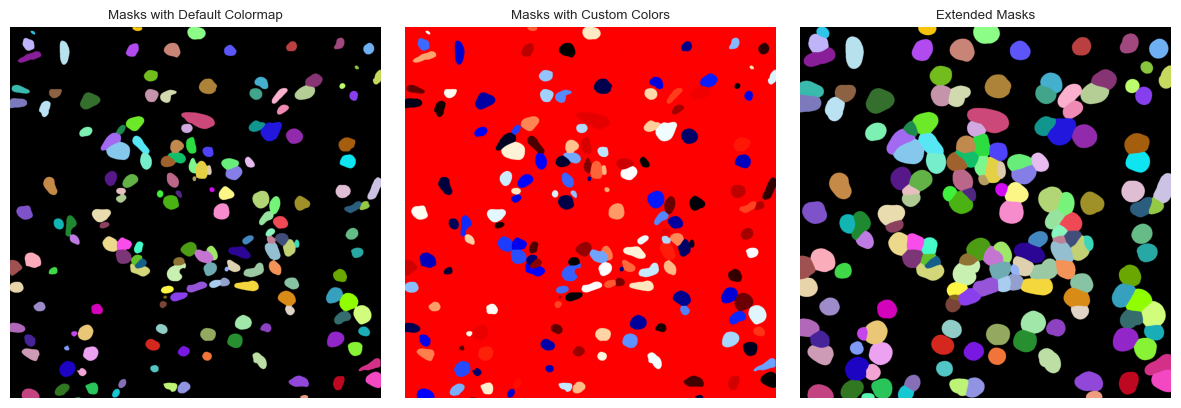

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

ax1 = so.plot.cluster_image(masks, title="Masks with Default Colormap", show_colorbar=False, ax=axes[0])
ax2 = so.plot.cluster_image(masks, colormap="flag", show_colorbar=False, title="Masks with Custom Colors", ax=axes[1])
ax3 = so.plot.cluster_image(extended_masks, ax=axes[2], show_colorbar=False, title="Extended Masks")

plt.tight_layout()

## Session info


In [20]:
info = session_info(
    cpu=True,
    gpu=True,
)  # note that the output cannot be copied in the compiled docs version of this notebook
info

Package,Version
pandas,2.2.3
matplotlib,3.10.6
numpy,2.3.3
spatiomic,0.9.2
igraph,0.11.9
Component,Info
Python,"3.13.5 (main, Jun 12 2025, 12:22:43) [Clang 20.1.4 ]"
OS,macOS-15.7.2-arm64-arm-64bit-Mach-O
CPU,"12 logical CPU cores, arm"
GPU,No GPU found
